# Minimal Prediction vs Ground Truth

Load `prediction.nc`, print per-step MSE, and plot GT/prediction/difference for first `N` steps.


In [23]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

PREDICTION_NC = Path("/nas/rgroup/aifm/rohit/Surya/easy_inference/outputs_24h/prediction.nc")
SAMPLE_IDX = 0
CHANNEL = "aia94"  # change if needed
N_PLOT_STEPS = 3


In [24]:
ds = xr.open_dataset(PREDICTION_NC, engine="h5netcdf")
meta_vars = {"sample_id", "input_timestamps", "prediction_timestamps", "channel_names"}
pred_vars = [v for v in ds.data_vars if (not v.startswith("gt_")) and (v not in meta_vars)]
if CHANNEL not in pred_vars:
    CHANNEL = pred_vars[0]
    print(f"CHANNEL not found. Using: {CHANNEL}")

pred = ds[CHANNEL].isel(sample=SAMPLE_IDX).values.astype(np.float32)
gt = ds[f"gt_{CHANNEL}"].isel(sample=SAMPLE_IDX).values.astype(np.float32)

step_mse = []
for step_idx in range(pred.shape[0]):
    valid = np.isfinite(gt[step_idx])
    if valid.any():
        mse = float(np.mean((pred[step_idx][valid] - gt[step_idx][valid]) ** 2))
        step_mse.append(mse)
        print(f"step {step_idx + 1:02d}: MSE={mse:.6f}")
    else:
        step_mse.append(np.nan)
        print(f"step {step_idx + 1:02d}: GT missing")


step 01: MSE=0.782106
step 02: MSE=0.421440
step 03: MSE=0.442715
step 04: MSE=0.551782
step 05: MSE=3.435462
step 06: MSE=0.932981


/tmp/ipykernel_1065677/614617498.py:4: RuntimeWarning: invalid value encountered in log1p
  gt_tr,pred_tr = np.log1p(gt),np.log1p(pred)


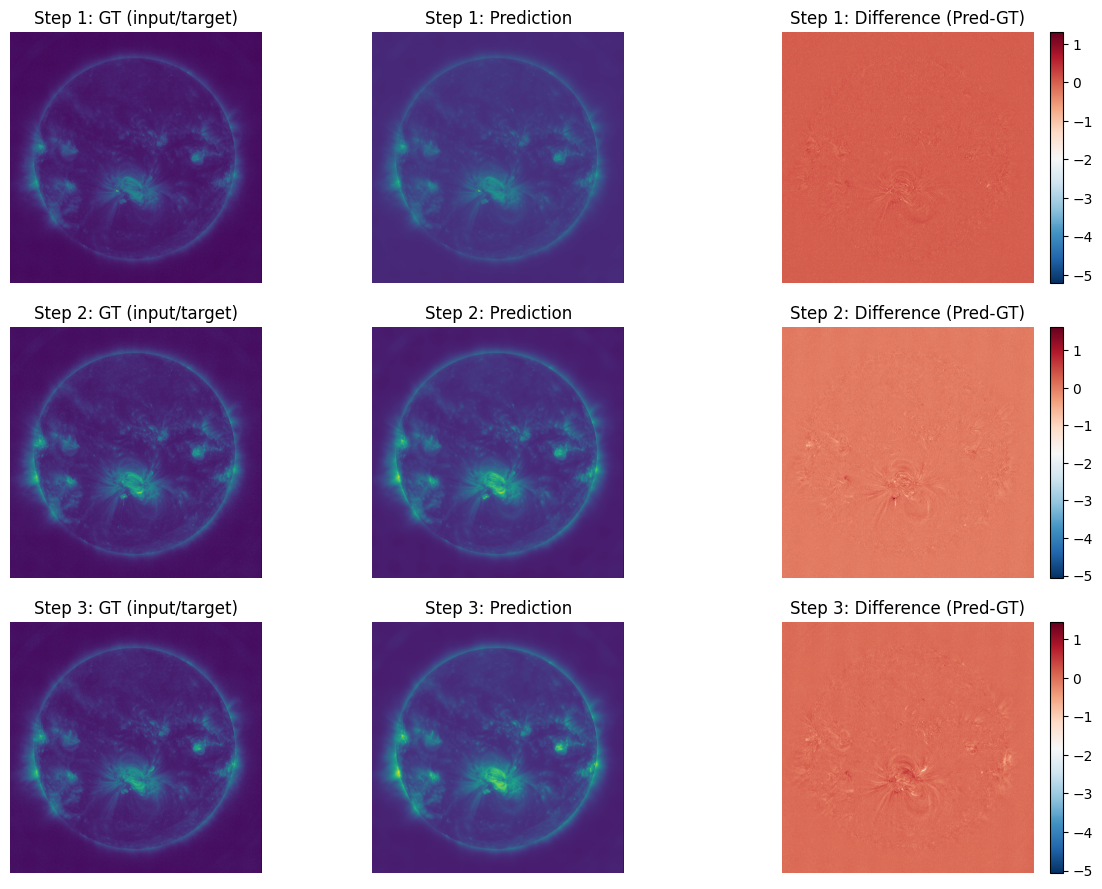

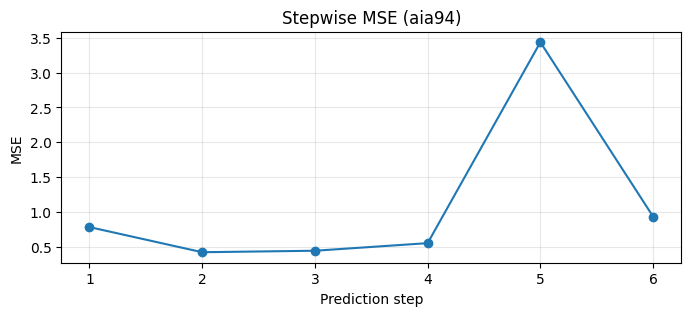

In [25]:
n = min(N_PLOT_STEPS, pred.shape[0])
fig, axes = plt.subplots(n, 3, figsize=(12, 3 * n), squeeze=False)
for i in range(n):
    gt_tr,pred_tr = np.log1p(gt),np.log1p(pred)
    diff = np.where(np.isfinite(gt_tr[i]), pred_tr[i] - gt_tr[i], np.nan)
    axes[i, 0].imshow(gt_tr[i], origin="lower")
    axes[i, 0].set_title(f"Step {i + 1}: GT (input/target)")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(pred_tr[i], origin="lower")
    axes[i, 1].set_title(f"Step {i + 1}: Prediction")
    axes[i, 1].axis("off")

    im = axes[i, 2].imshow(diff, origin="lower", cmap="RdBu_r")
    axes[i, 2].set_title(f"Step {i + 1}: Difference (Pred-GT)")
    axes[i, 2].axis("off")
    fig.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
x = np.arange(1, len(step_mse) + 1)
plt.plot(x, step_mse, marker="o")
plt.xlabel("Prediction step")
plt.ylabel("MSE")
plt.title(f"Stepwise MSE ({CHANNEL})")
plt.grid(alpha=0.3)
plt.show()
